In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("sample_citibike_2023.csv")

/tmp/ipython-input-10499/4175258315.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_citibike_2023.csv")


In [ ]:
df.head()

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,12536574,6A1558E5EB8E9B3B,classic_bike,2023-06-25 06:44:47,2023-06-25 07:02:43,Walton Ave & E 168 St,8179.03,Icahn Stadium,7514.01,40.836655,-73.918324,40.793460,-73.923890,member
1,20766033,F5DAABF8EAD39B32,classic_bike,2023-08-15 18:05:37,2023-08-15 18:12:06,Grand Army Plaza & Central Park S,6839.10,2 Ave & E 72 St,6925.09,40.764004,-73.973974,40.768762,-73.958408,member
2,17246346,CC4D3C1C193EBCDD,classic_bike,2023-07-05 15:00:28,2023-07-05 15:06:34,Knickerbocker Ave & Thames St,5018.06,Melrose St & Broadway,4801.04,40.705446,-73.929975,40.697481,-73.935877,casual
3,3860641,541D7A53817AF238,classic_bike,2023-03-05 11:29:02,2023-03-05 11:36:36,DeKalb Ave & Vanderbilt Ave,4461.04,Pacific St & Classon Ave,4148.07,40.689425,-73.968898,40.679194,-73.958790,member
4,27285265,EACA2B802BFED979,classic_bike,2023-10-17 15:02:23,2023-10-17 15:06:40,Liberty St & Broadway,5105.01,West Thames St,5114.06,40.708164,-74.010369,40.708347,-74.017134,member


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1000000 non-null  int64  
 1   ride_id             1000000 non-null  object 
 2   rideable_type       1000000 non-null  object 
 3   started_at          1000000 non-null  object 
 4   ended_at            1000000 non-null  object 
 5   start_station_name  999459 non-null   object 
 6   start_station_id    999459 non-null   object 
 7   end_station_name    997192 non-null   object 
 8   end_station_id      997192 non-null   object 
 9   start_lat           1000000 non-null  float64
 10  start_lng           1000000 non-null  float64
 11  end_lat             999287 non-null   float64
 12  end_lng             999287 non-null   float64
 13  member_casual       1000000 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 106.8+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,541
start_station_id,541
end_station_name,2808
end_station_id,2808
start_lat,0


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [ ]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print('-' * 40)

ride_id
['6A1558E5EB8E9B3B' 'F5DAABF8EAD39B32' 'CC4D3C1C193EBCDD' ...
 '2892D1DA3F9483A1' '5FE9361CFBB85827' 'FFA3FFC5C92389D7']
----------------------------------------
rideable_type
['classic_bike' 'electric_bike' 'docked_bike']
----------------------------------------
started_at
['2023-06-25 06:44:47' '2023-08-15 18:05:37' '2023-07-05 15:00:28' ...
 '2023-02-04 15:04:44' '2023-08-16 18:06:38' '2023-05-18 20:36:48']
----------------------------------------
ended_at
['2023-06-25 07:02:43' '2023-08-15 18:12:06' '2023-07-05 15:06:34' ...
 '2023-02-04 15:07:40' '2023-08-16 18:22:09' '2023-05-18 20:40:43']
----------------------------------------
start_station_name
['Walton Ave & E 168 St' 'Grand Army Plaza & Central Park S'
 'Knickerbocker Ave & Thames St' ...
 'Hoboken Terminal - Hudson St & Hudson Pl' 'Corona Ave & 92 St'
 'Broadway & Van Cortlandt Park S']
----------------------------------------
start_station_id
['8179.03' '6839.10' '5018.06' ... 8547.04 4064.03 8535.01]
------------

In [ ]:
df = df.drop(columns=['Unnamed: 0','ride_id','start_station_id','end_station_id'],axis=1)

In [ ]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [ ]:
df['ride_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['start_hour'] = df['started_at'].dt.hour
df['start_day'] = df['started_at'].dt.dayofweek
df['month'] = df['started_at'].dt.month

In [ ]:
df['member_casual'] = df['member_casual'].map({
    'member': 1,
    'casual': 0
})

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [ ]:
# Numeric
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

* Noticed that ride_duration has negatine min value and max 11 days which is
impossible. Heavily skewed wil log transform it.
* member column has heavy imbalance. 81% are members and 19% are casual

In [ ]:
df[num_cols].describe()

,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,start_hour,start_day,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.740204,-73.972587,40.740071,-73.972662,0.814572,14.849927,14.068359,2.918891,6.936009
std,0.040891,0.028043,0.040866,0.028053,0.388645,60.943801,5.053448,1.935825,3.085697
min,40.597389,-74.026852,40.610000,-74.080000,0.000000,-53.933333,0.000000,0.000000,1.000000
25%,40.715030,-73.992530,40.715030,-73.992663,1.000000,5.000000,10.000000,1.000000,5.000000
50%,40.739126,-73.980166,40.739017,-73.980144,1.000000,9.033333,15.000000,3.000000,7.000000
75%,40.763278,-73.955857,40.763154,-73.955931,1.000000,16.183333,18.000000,5.000000,9.000000
max,40.890000,-73.814664,40.920000,-73.800000,1.000000,16896.933333,23.000000,6.000000,12.000000


In [ ]:
df[cat_cols].describe()

,rideable_type,start_station_name,end_station_name
count,1000000,1000000,1000000
unique,3,2221,2244
top,classic_bike,W 21 St & 6 Ave,W 21 St & 6 Ave
freq,897184,4586,6805


In [ ]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"IQR: {IQR}")
    print(f"Outliers: {outliers.shape[0]}")


Column: start_lat
IQR: 0.0482483947499972
Outliers: 23990

Column: start_lng
IQR: 0.03667278274998864
Outliers: 16102

Column: end_lat
IQR: 0.04812400000000139
Outliers: 24507

Column: end_lng
IQR: 0.03673207999999306
Outliers: 16313

Column: member_casual
IQR: 0.0
Outliers: 185428

Column: ride_duration
IQR: 11.183333333333334
Outliers: 65295

Column: start_hour
IQR: 8.0
Outliers: 0

Column: start_day
IQR: 4.0
Outliers: 0

Column: month
IQR: 4.0
Outliers: 0


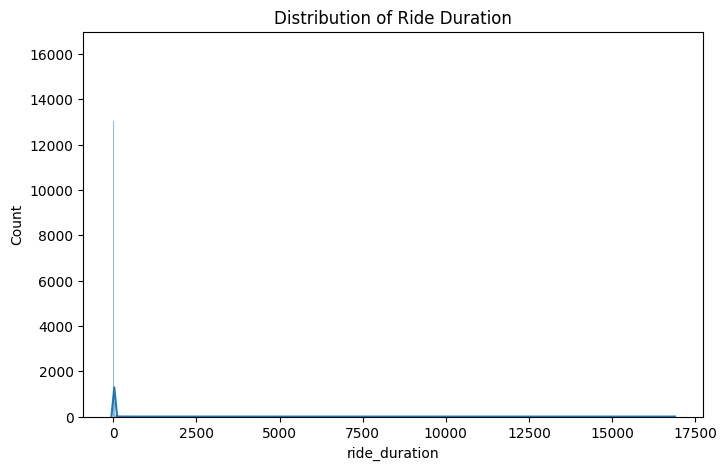

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['ride_duration'], kde=True)
plt.title("Distribution of Ride Duration")
plt.show()

In [ ]:
print("Skew:", df['ride_duration'].skew())

Skew: 81.54315008378161


In [ ]:
df[df['ride_duration'] <= 0]

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,start_hour,start_day,month
3240,electric_bike,2023-08-12 09:57:36,2023-08-12 09:57:36,Prospect Park W & 20 St,Prospect Park W & 20 St,40.656633,-73.983864,40.656633,-73.983864,1,0.000000,9,5,8
3495,classic_bike,2023-02-08 19:16:10,2023-02-08 19:16:10,W 18 St & 6 Ave,W 18 St & 6 Ave,40.739713,-73.994564,40.739713,-73.994564,1,0.000000,19,2,2
5267,classic_bike,2023-07-02 22:12:20,2023-07-02 22:12:20,Lafayette Ave & St James Pl,Lafayette Ave & St James Pl,40.688515,-73.964763,40.688515,-73.964763,1,0.000000,22,6,7
5646,classic_bike,2023-07-06 11:54:40,2023-07-06 11:54:40,Roebling St & N 4 St,Roebling St & N 4 St,40.714690,-73.957390,40.714690,-73.957390,1,0.000000,11,3,7
5714,classic_bike,2023-12-27 20:38:58,2023-12-27 20:38:58,43 St & Broadway,43 St & Broadway,40.757696,-73.916681,40.757728,-73.916637,1,0.000000,20,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987780,classic_bike,2023-04-24 15:35:57,2023-04-24 15:35:57,E 118 St & 3 Ave,E 118 St & 3 Ave,40.799171,-73.938846,40.799139,-73.938915,1,0.000000,15,0,4
988073,classic_bike,2023-05-27 17:12:10,2023-05-27 17:12:10,Wilkins Ave & Crotona Park E,Wilkins Ave & Crotona Park E,40.835247,-73.895095,40.835302,-73.895133,0,0.000000,17,5,5
993572,classic_bike,2023-09-08 08:45:24,2023-09-08 08:45:24,W 45 St & 8 Ave,W 45 St & 8 Ave,40.759291,-73.988597,40.759291,-73.988597,1,0.000000,8,4,9
997850,classic_bike,2023-10-17 12:21:14,2023-10-17 12:21:13,E 89 St & 3 Ave,E 89 St & 3 Ave,40.780736,-73.952507,40.780628,-73.952167,1,-0.016667,12,1,10


In [ ]:
df = df[df['ride_duration'] > 0]
df['ride_duration'] = np.log1p(df['ride_duration'])
print("New Skew:", df['ride_duration'].skew())

New Skew: 0.22510407902920454


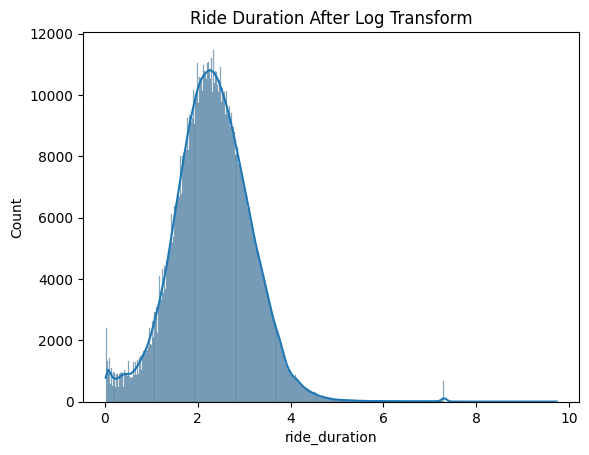

In [ ]:
sns.histplot(df['ride_duration'], kde=True)
plt.title("Ride Duration After Log Transform")
plt.show()

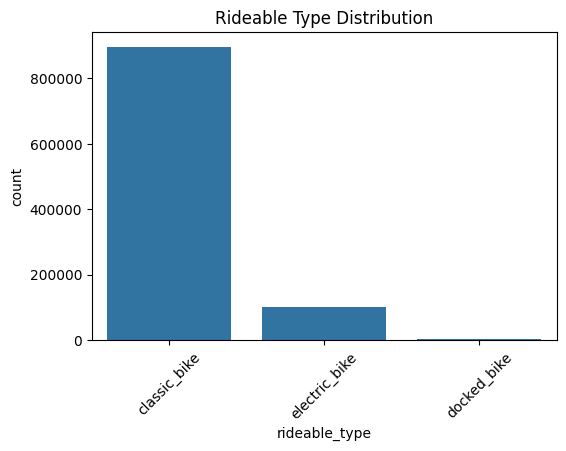

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='rideable_type')
plt.title("Rideable Type Distribution")
plt.xticks(rotation=45)
plt.show()

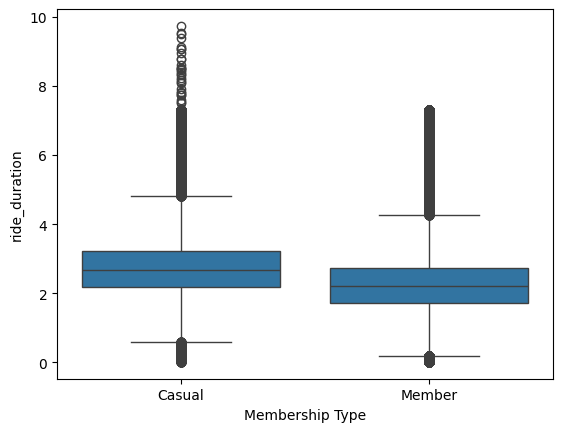

In [ ]:
sns.boxplot(
    data=df,
    x='member_casual',
    y='ride_duration'
)

plt.xticks([0,1], ['Casual', 'Member'])
plt.xlabel("Membership Type")
plt.show()

In [ ]:
pd.crosstab(df['ride_duration'], df['member_casual'])

member_casual,0,1
ride_duration,,
0.016529,45,800
0.032790,90,1474
0.048790,91,1235
0.064539,67,872
0.080043,42,676
...,...,...
9.136146,1,0
9.376293,1,0
9.511447,1,0


In [ ]:
num_features = [
    'ride_duration',
    'start_day',
    'month'
]

cat_features = ['member_casual']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('kmeans', KMeans(random_state=42))
])


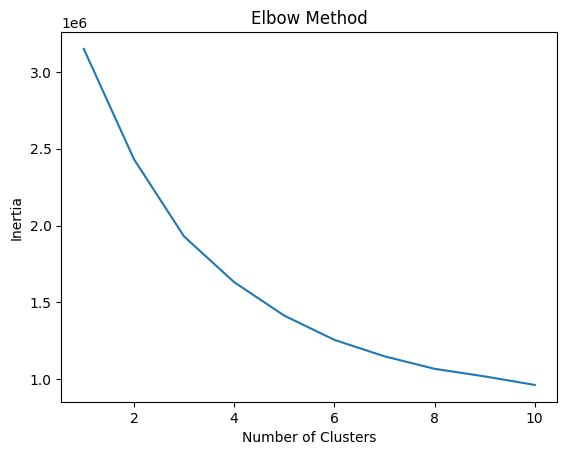

In [ ]:
inertia = []

for k in range(1, 11):
    pipeline.set_params(kmeans__n_clusters=k)
    pipeline.fit(df)
    inertia.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
pipeline.set_params(kmeans__n_clusters=4)
pipeline.fit(df)

df['cluster'] = pipeline.named_steps['kmeans'].labels_

In [ ]:
# Get transformed data
X_processed = pipeline.named_steps['preprocessing'].transform(df)

score = silhouette_score(
    X_processed,
    df['cluster'],
    sample_size=10000,
    random_state=42
)

print("Silhouette Score:", score)

Silhouette Score: 0.23805122548174887


In [ ]:
from sklearn.metrics import adjusted_rand_score

kmeans1 = KMeans(n_clusters=4, random_state=42, n_init=20)
labels1 = kmeans1.fit_predict(X_processed)

kmeans2 = KMeans(n_clusters=4, random_state=99, n_init=20)
labels2 = kmeans2.fit_predict(X_processed)

ari = adjusted_rand_score(labels1, labels2)
print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.9775908826511636


In [ ]:
# Get transformed feature matrix
X_processed = pipeline.named_steps['preprocessing'].transform(df)

# Add cluster labels
df['cluster'] = pipeline.named_steps['kmeans'].labels_
cluster_labels = {
    0: "Fall Weekday Members",
    1: "Active Summer Members",
    2: "Summer Casual Riders",
    3: "Spring Weekday Members"
}

df['cluster_name'] = df['cluster'].map(cluster_labels)

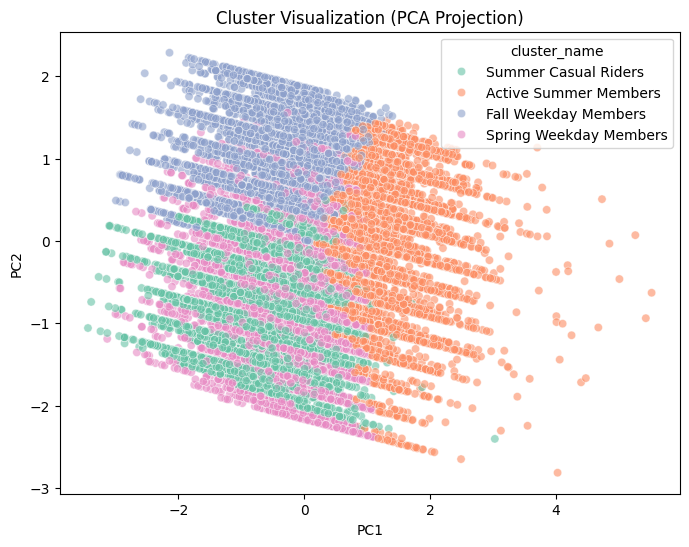

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Create temporary dataframe
viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster_name': df['cluster_name']
})

# Sample for speed
viz_sample = viz_df.sample(20000, random_state=42)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=viz_sample,
    x='PC1',
    y='PC2',
    hue='cluster_name',
    palette='Set2',
    alpha=0.6
)

plt.title("Cluster Visualization (PCA Projection)")
plt.show()

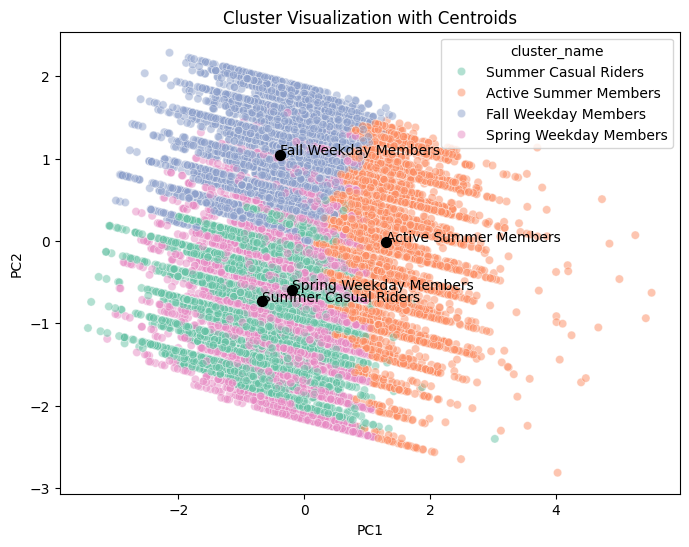

In [ ]:
centroids = viz_sample.groupby('cluster_name')[['PC1','PC2']].mean()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=viz_sample,
    x='PC1',
    y='PC2',
    hue='cluster_name',
    palette='Set2',
    alpha=0.5
)

plt.scatter(
    centroids['PC1'],
    centroids['PC2'],
    s=50,
    c='black',
    marker='o'
)

for cluster, row in centroids.iterrows():
    plt.text(row['PC1'], row['PC2'], cluster, fontsize=10)

plt.title("Cluster Visualization with Centroids")
plt.show()

In [ ]:
df.groupby('cluster_name')[
    ['ride_duration', 'start_day', 'month', 'member_casual']
].mean()

,ride_duration,start_day,month,member_casual
cluster_name,,,,
Active Summer Members,3.037089,4.598220,8.042868,0.663659
Fall Weekday Members,2.096900,1.615599,9.615864,0.864758
Spring Weekday Members,1.627243,4.513441,5.367588,0.883337
Summer Casual Riders,2.444214,1.370695,4.004731,0.847690
